# SC4000: Machine Learning - Elo Merchant Category Recommendation

## Introduction
This notebook presents a solution to the [Elo Merchant Category Recommendation](https://www.kaggle.com/c/elo-merchant-category-recommendation) Kaggle competition. The goal of this competition is to predict the loyalty score for credit card customers based on their transaction history.

Elo, one of the largest payment brands in Brazil, has built partnerships with merchants to offer promotions or discounts to cardholders. But to deliver the right promotions to the right customers, they need to understand the customer's preferences. In this competition, we build a model that predicts a loyalty score for each customer based on their transaction patterns.

## Project Overview

Our solution follows these main steps:

1. **Data Loading and Exploration**: Load the datasets and explore their structure
2. **Feature Engineering**: Create meaningful features from transaction data
3. **Model Training**: Train a LightGBM model with cross-validation
4. **Evaluation**: Evaluate model performance using RMSE
5. **Prediction**: Generate predictions for the test set

The following section imports the necessary libraries for the project.

## Import Libraries
This section imports the necessary Python libraries for data manipulation, file operations, and machine learning.


In [1]:
# Import necessary libraries
import pandas as pd          # For data manipulation and analysis
import numpy as np           # For numerical operations
import os                    # For file path operations
import gc                    # For garbage collection to manage memory
from sklearn.model_selection import KFold  # For cross-validation
from sklearn.metrics import mean_squared_error  # For model evaluation
import lightgbm as lgb       # Gradient boosting framework
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns        # For enhanced visualizations

# Set visualization style for better readability and aesthetics
plt.style.use('fivethirtyeight')  # FiveThirtyEight style for plots
sns.set(style='whitegrid')        # Clean grid style for seaborn plots

In [2]:
from os.path import isfile

def save_submission_k(submission):
# Save submission file
    filepath = "data/submission.csv"
    i = 1
    while isfile(filepath):
        filepath = f"data/submission{i}.csv"
        i += 1
    submission.to_csv(filepath, index=False)
    print(f"Submission file {filepath} created with RMSE: {rmse}")

## Data Loading

This section sets the path to the data files and loads them. The competition provides several datasets:

- **train.csv**: Training data with card_id and target loyalty score
- **test.csv**: Test data for which predictions need to be made
- **historical_transactions.csv**: Historical transactions for each card
- **new_merchant_transactions.csv**: New transactions for each card
- **merchants.csv**: Information about merchants

The following code defines the data path and loads the train and test datasets.


In [15]:
# Set data path - adjust this to your local environment
# If running on Kaggle, use: DATA_PATH = '/kaggle/input/elo-merchant-category-recommendation/'
# If running locally, use the path to your data directory
DATA_PATH = './data/'

# Load train and test data
print("Loading train and test data...")
# Train data contains card_id and the target loyalty score
train = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
# Test data contains card_id for which we need to predict the loyalty score
test = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))

# Display basic information about the datasets
print(f"Train shape: {train.shape}")  # Number of rows and columns in train data
print(f"Test shape: {test.shape}")    # Number of rows and columns in test data

# Display first few rows of train data to understand its structure
# This helps us see the columns and data types
train.head()


Loading train and test data...
Train shape: (201917, 6)
Test shape: (123623, 5)


,first_active_month,card_id,feature_1,feature_2,feature_3,target
0,2017-06,C_ID_92a2005557,5,2,1,-0.820283
1,2017-01,C_ID_3d0044924f,4,1,0,0.392913
2,2016-08,C_ID_d639edf6cd,2,2,0,0.688056
3,2017-09,C_ID_186d6a6901,4,3,0,0.142495
4,2017-11,C_ID_cdbd2c0db2,1,3,0,-0.159749


### Exploring the Target Variable

This section examines the distribution of the target variable (loyalty score) to better understand the prediction objective.


C:\Users\l\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


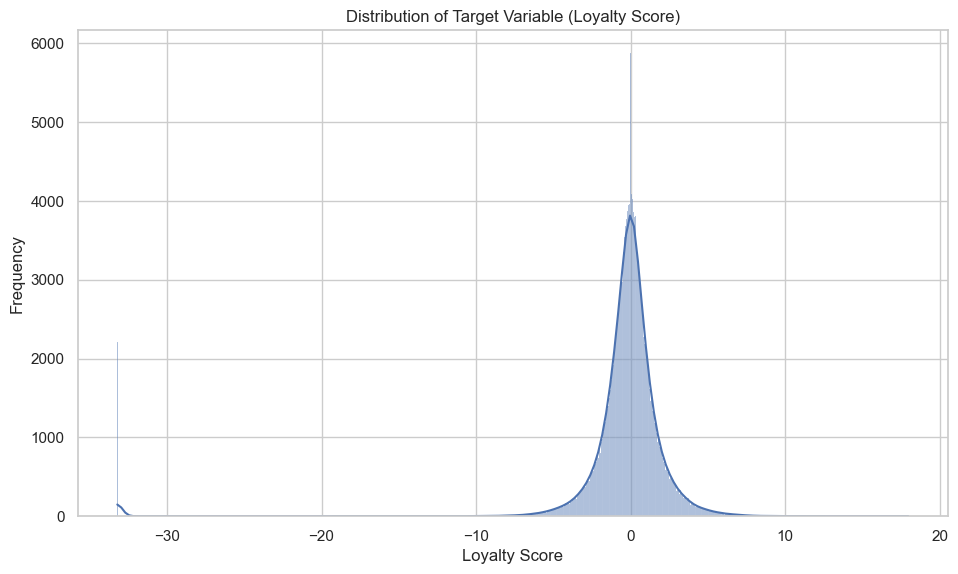

Target statistics:
count    201917.000000
mean         -0.393636
std           3.850500
min         -33.219281
25%          -0.883110
50%          -0.023437
75%           0.765453
max          17.965068
Name: target, dtype: float64


In [16]:
# Plot target distribution
plt.figure(figsize=(10, 6))
sns.histplot(train['target'], kde=True)
plt.title('Distribution of Target Variable (Loyalty Score)')
plt.xlabel('Loyalty Score')
plt.ylabel('Frequency')
plt.show()

# Display basic statistics of target
print("Target statistics:")
print(train['target'].describe())


## Feature Engineering

### Processing First Active Month

This section processes the 'first_active_month' feature in both train and test datasets. The code converts it to datetime and extracts useful features like year, month, and elapsed months.


Reference date (latest in dataset): 2018-02-01


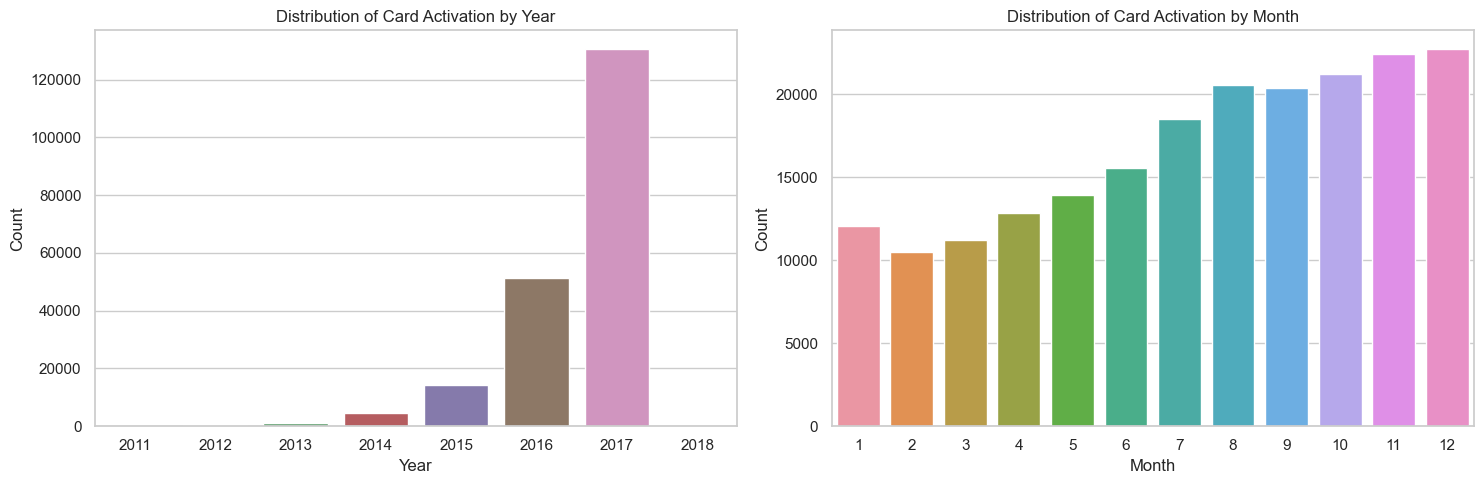

In [17]:
# Convert 'first_active_month' to datetime for both datasets
train['first_active_month'] = pd.to_datetime(train['first_active_month'])
test['first_active_month'] = pd.to_datetime(test['first_active_month'])

# Find the latest 'first_active_month' date across both datasets
combined = pd.concat([train['first_active_month'], test['first_active_month']])
latest_date = combined.max()
print("Reference date (latest in dataset):", latest_date.date())

# Process temporal features
for df in [train, test]:
    # Extract year and month
    df['year'] = df['first_active_month'].dt.year
    df['month'] = df['first_active_month'].dt.month

    # Calculate elapsed time from activation to latest date
    elapsed_days = (latest_date - df['first_active_month']).dt.days
    df['elapsed_months'] = (elapsed_days / 30).fillna(0).astype(int)

    # Drop original date column
    df.drop('first_active_month', axis=1, inplace=True)

# Visualize distribution of card activation
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='year', data=train)
plt.title('Distribution of Card Activation by Year')
plt.xlabel('Year')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='month', data=train)
plt.title('Distribution of Card Activation by Month')
plt.xlabel('Month')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


### Loading Transaction Data

This section loads the transaction data. There are two transaction datasets:
1. Historical transactions
2. New merchant transactions

These datasets contain detailed information about each transaction made by the cardholders.


In [18]:
# Load historical transactions
print("Loading historical transactions...")
hist_trans = pd.read_csv(os.path.join(DATA_PATH, 'historical_transactions.csv'))

# Load new transactions
print("Loading new transactions...")
new_trans = pd.read_csv(os.path.join(DATA_PATH, 'new_merchant_transactions.csv'))

# Display basic information
print(f"Historical transactions shape: {hist_trans.shape}")
print(f"New transactions shape: {new_trans.shape}")

# Display first few rows of historical transactions
hist_trans.head()


Loading historical transactions...
Loading new transactions...
Historical transactions shape: (29112361, 14)
New transactions shape: (1963031, 14)


,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37


### Processing Categorical Features

This section processes the categorical features in the transaction datasets by converting them to numerical values.


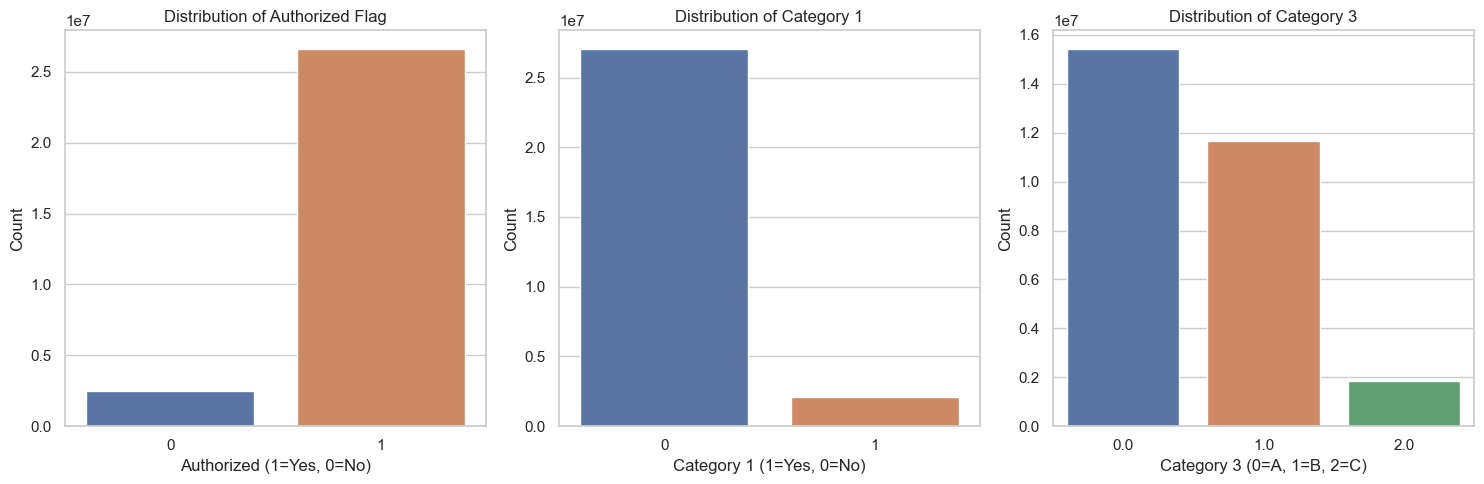

In [19]:
# Process categorical features - Convert string categories to numeric values for modeling
for df in [hist_trans, new_trans]:
    # Convert binary flag for transaction authorization (Y/N) to numeric (1/0)
    # This indicates whether the transaction was authorized or declined
    df['authorized_flag'] = df['authorized_flag'].map({'Y': 1, 'N': 0})

    # Convert binary category_1 flag (Y/N) to numeric (1/0)
    # According to the data dictionary, this relates to transaction attributes
    df['category_1'] = df['category_1'].map({'Y': 1, 'N': 0})

    # Convert ordinal category_3 values (A/B/C) to numeric (0/1/2)
    # This preserves the ordinal relationship between categories
    df['category_3'] = df['category_3'].map({'A': 0, 'B': 1, 'C': 2})

# Visualize distribution of categorical features
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='authorized_flag', data=hist_trans)
plt.title('Distribution of Authorized Flag')
plt.xlabel('Authorized (1=Yes, 0=No)')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.countplot(x='category_1', data=hist_trans)
plt.title('Distribution of Category 1')
plt.xlabel('Category 1 (1=Yes, 0=No)')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.countplot(x='category_3', data=hist_trans)
plt.title('Distribution of Category 3')
plt.xlabel('Category 3 (0=A, 1=B, 2=C)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


### Feature Aggregation Function

This section defines a function to aggregate transaction data and create meaningful features. This function:
1. Groups transactions by card_id
2. Calculates various statistics for each group
3. Creates time-based features
4. Counts transactions by category and merchant


In [21]:
def aggregate_transactions(df, prefix):
    """
    Aggregate transaction data to create features

    Parameters:
    -----------
    df : pandas DataFrame
        Transaction data
    prefix : str
        Prefix to add to column names (e.g., 'hist_' or 'new_')

    Returns:
    --------
    agg_df : pandas DataFrame
        Aggregated features
    """
    # Count transactions
    agg_func = {
        'authorized_flag': ['sum', 'mean'],
        'card_id': ['size'],
        'city_id': ['nunique'],
        'category_1': ['sum', 'mean'],
        'installments': ['sum', 'mean', 'max', 'min', 'std'],
        'category_3': ['nunique'],
        'merchant_category_id': ['nunique'],
        'merchant_id': ['nunique'],
        'month_lag': ['mean', 'max', 'min', 'std'],
        'purchase_amount': ['sum', 'mean', 'max', 'min', 'std'],
        'category_2': ['nunique'],
        'state_id': ['nunique'],
        'subsector_id': ['nunique']
    }

    # Group by card_id and aggregate
    agg_df = df.groupby(['card_id']).agg(agg_func)

    # Flatten column names
    agg_df.columns = [prefix + '_'.join(col).strip() for col in agg_df.columns.values]
    agg_df.reset_index(inplace=True)

    # Create time-based features
    df['month_diff'] = df['month_lag'].diff().fillna(0)
    df['month_diff'] = df['month_diff'].astype(int)
    df['month_diff'] = df['month_diff'].apply(lambda x: x if x <= 1 else 0)
    df['purchase_date'] = pd.to_datetime(df['purchase_date'])

    # Extract date features
    df['month'] = df['purchase_date'].dt.month
    df['hour'] = df['purchase_date'].dt.hour
    df['weekday'] = df['purchase_date'].dt.weekday
    df['weekofyear'] = df['purchase_date'].dt.isocalendar().week
    df['day'] = df['purchase_date'].dt.day
    df['elapsed_days'] = (df['purchase_date'] - df['purchase_date'].min()).dt.days

    # Aggregate time-based features
    agg_func = {
        'month_diff': ['mean'],
        'month': ['mean', 'min', 'max'],
        'hour': ['mean', 'min', 'max'],
        'weekday': ['mean', 'min', 'max'],
        'weekofyear': ['mean', 'min', 'max'],
        'day': ['mean', 'min', 'max'],
        'elapsed_days': ['mean', 'min', 'max']
    }
    agg_df_time = df.groupby(['card_id']).agg(agg_func)
    agg_df_time.columns = [prefix + '_'.join(col).strip() for col in agg_df_time.columns.values]
    agg_df_time.reset_index(inplace=True)

    # Merge time-based features
    agg_df = pd.merge(agg_df, agg_df_time, on='card_id', how='left')

    # Count transactions by category
    for col in ['category_1', 'category_2', 'category_3']:
        temp_df = df.groupby(['card_id', col])[['purchase_amount']].size().unstack().reset_index()
        temp_df.columns = ['card_id'] + [prefix + col + '_' + str(i) + '_count' for i in temp_df.columns[1:]]
        agg_df = pd.merge(agg_df, temp_df, on='card_id', how='left')

    # Count transactions by merchant
    for col in ['merchant_id', 'merchant_category_id']:
        temp_df = df.groupby(['card_id'])[col].nunique().reset_index()
        temp_df.columns = ['card_id', prefix + col + '_nunique']
        agg_df = pd.merge(agg_df, temp_df, on='card_id', how='left')

    # Count transactions by month_lag
    for i in range(-12, 3):
        temp_df = df[df['month_lag'] == i].groupby(['card_id'])[['purchase_amount']].count().reset_index()
        temp_df.columns = ['card_id', prefix + 'month_lag_' + str(i) + '_count']
        agg_df = pd.merge(agg_df, temp_df, on='card_id', how='left')

    # Fill NAs
    agg_df.fillna(0, inplace=True)

    return agg_df


### Merging and More Features

This section adds more features and merges them all into relevant train and test datasets


In [22]:
# # 1
# # Recent vs Early Transaction Trends Captures behavior changes over time. Let’s define recent = last 3 months.
# recent = hist_trans[hist_trans['month_lag'] >= -3].groupby('card_id')['purchase_amount'].mean().reset_index()
# recent.columns = ['card_id', 'recent_purchase_mean']

# earlier = hist_trans[hist_trans['month_lag'] < -3].groupby('card_id')['purchase_amount'].mean().reset_index()
# earlier.columns = ['card_id', 'earlier_purchase_mean']

# trend_df = pd.merge(recent, earlier, on='card_id', how='outer')
# trend_df['purchase_amount_trend'] = trend_df['recent_purchase_mean'] - trend_df['earlier_purchase_mean']

# train = pd.merge(train, trend_df[['card_id', 'purchase_amount_trend']], on='card_id', how='left')
# test = pd.merge(test, trend_df[['card_id', 'purchase_amount_trend']], on='card_id', how='left')


In [23]:
# # 1
# # Decline Rate, rejected transactions may signal poor cardholder experience
# hist_trans['declined'] = 1 - hist_trans['authorized_flag']
# decline_rate = hist_trans.groupby('card_id')['declined'].mean().reset_index()
# decline_rate.columns = ['card_id', 'hist_decline_rate']

# train = pd.merge(train, decline_rate, on='card_id', how='left')
# test = pd.merge(test, decline_rate, on='card_id', how='left')


In [24]:
# # 1
# # Merchant Diversity via Entropy
# def calc_entropy(series):
#     probs = series.value_counts(normalize=True)
#     return -(probs * np.log(probs + 1e-6)).sum()

# merchant_entropy = hist_trans.groupby('card_id')['merchant_id'].agg(calc_entropy).reset_index()
# merchant_entropy.columns = ['card_id', 'merchant_entropy']

# train = pd.merge(train, merchant_entropy, on='card_id', how='left')
# test = pd.merge(test, merchant_entropy, on='card_id', how='left')


In [25]:
# Recency Features – Time Since Last Historical Purchase
last_hist = hist_trans.groupby('card_id')['purchase_date'].max().reset_index()
last_hist.columns = ['card_id', 'hist_last_purchase']
last_hist['hist_days_since_last'] = (pd.to_datetime('2018-02-01') - pd.to_datetime(last_hist['hist_last_purchase'])).dt.days
last_hist.drop('hist_last_purchase', axis=1, inplace=True)

train = pd.merge(train, last_hist, on='card_id', how='left')
test = pd.merge(test, last_hist, on='card_id', how='left')

In [26]:
# Transaction Frequency – Days Between Transactions
hist_trans_sorted = hist_trans.sort_values(['card_id', 'purchase_date'])
hist_trans_sorted['purchase_date'] = pd.to_datetime(hist_trans_sorted['purchase_date'])
hist_trans_sorted['prev_date'] = hist_trans_sorted.groupby('card_id')['purchase_date'].shift(1)
hist_trans_sorted['days_between'] = (hist_trans_sorted['purchase_date'] - hist_trans_sorted['prev_date']).dt.days

gap_stats = hist_trans_sorted.groupby('card_id')['days_between'].agg(['mean', 'std', 'min', 'max']).reset_index()
gap_stats.columns = ['card_id', 'days_between_mean', 'days_between_std', 'days_between_min', 'days_between_max']

train = pd.merge(train, gap_stats, on='card_id', how='left')
test = pd.merge(test, gap_stats, on='card_id', how='left')

In [27]:
# Customer Behavior – Weekend Purchase Ratio
hist_trans['purchase_date'] = pd.to_datetime(hist_trans['purchase_date'])
hist_trans['is_weekend'] = hist_trans['purchase_date'].dt.weekday >= 5
weekend_ratio = hist_trans.groupby('card_id')['is_weekend'].mean().reset_index()
weekend_ratio.columns = ['card_id', 'hist_weekend_ratio']

train = pd.merge(train, weekend_ratio, on='card_id', how='left')
test = pd.merge(test, weekend_ratio, on='card_id', how='left')

In [28]:
# Aggregate historical transactions
print("Aggregating historical transactions...")
hist_trans_agg = aggregate_transactions(hist_trans, 'hist_')

# Aggregate new transactions
print("Aggregating new transactions...")
new_trans_agg = aggregate_transactions(new_trans, 'new_')

# Display basic information
print(f"Historical transactions aggregated shape: {hist_trans_agg.shape}")
print(f"New transactions aggregated shape: {new_trans_agg.shape}")

# Display first few rows of aggregated historical transactions
hist_trans_agg.head()

Aggregating historical transactions...
Aggregating new transactions...
Historical transactions aggregated shape: (325540, 73)
New transactions aggregated shape: (290001, 73)


,card_id,hist_authorized_flag_sum,hist_authorized_flag_mean,hist_card_id_size,hist_city_id_nunique,hist_category_1_sum,hist_category_1_mean,hist_installments_sum,hist_installments_mean,hist_installments_max,...,hist_month_lag_-7_count,hist_month_lag_-6_count,hist_month_lag_-5_count,hist_month_lag_-4_count,hist_month_lag_-3_count,hist_month_lag_-2_count,hist_month_lag_-1_count,hist_month_lag_0_count,hist_month_lag_1_count,hist_month_lag_2_count
0,C_ID_00007093c1,114,0.765101,149,4,28,0.187919,192,1.288591,6,...,15.0,17.0,5.0,17.0,6.0,12.0,10.0,12.0,0.0,0.0
1,C_ID_0001238066,120,0.975610,123,18,2,0.016260,198,1.609756,10,...,0.0,0.0,2.0,11.0,23.0,37.0,26.0,24.0,0.0,0.0
2,C_ID_0001506ef0,62,0.939394,66,3,0,0.000000,1,0.015152,1,...,2.0,2.0,2.0,3.0,7.0,18.0,7.0,6.0,0.0,0.0
3,C_ID_0001793786,189,0.875000,216,10,2,0.009259,5,0.023148,1,...,16.0,30.0,4.0,37.0,29.0,34.0,38.0,20.0,0.0,0.0
4,C_ID_000183fdda,137,0.951389,144,9,4,0.027778,264,1.833333,10,...,0.0,6.0,22.0,25.0,9.0,26.0,28.0,28.0,0.0,0.0


In [29]:
# Merge all data
print("Merging all data...")
train = pd.merge(train, hist_trans_agg, on='card_id', how='left')
train = pd.merge(train, new_trans_agg, on='card_id', how='left')

test = pd.merge(test, hist_trans_agg, on='card_id', how='left')
test = pd.merge(test, new_trans_agg, on='card_id', how='left')

# Fill NAs
train.fillna(0, inplace=True)
test.fillna(0, inplace=True)

# Display basic information
print(f"Final train shape: {train.shape}")
print(f"Final test shape: {test.shape}")

Merging all data...
Final train shape: (201917, 161)
Final test shape: (123623, 160)


In [30]:
# Clean up memory
del hist_trans, new_trans, hist_trans_agg, new_trans_agg
gc.collect()

29

## Feature Importance Analysis

This section trains a simple model to identify which features are most important. This helps understand what drives the loyalty score prediction.


In [31]:
# # Clean non numeric
# for df in [train, test]:
#     if 'first_active_month' in df.columns:
#         df.drop('first_active_month', axis=1, inplace=True)

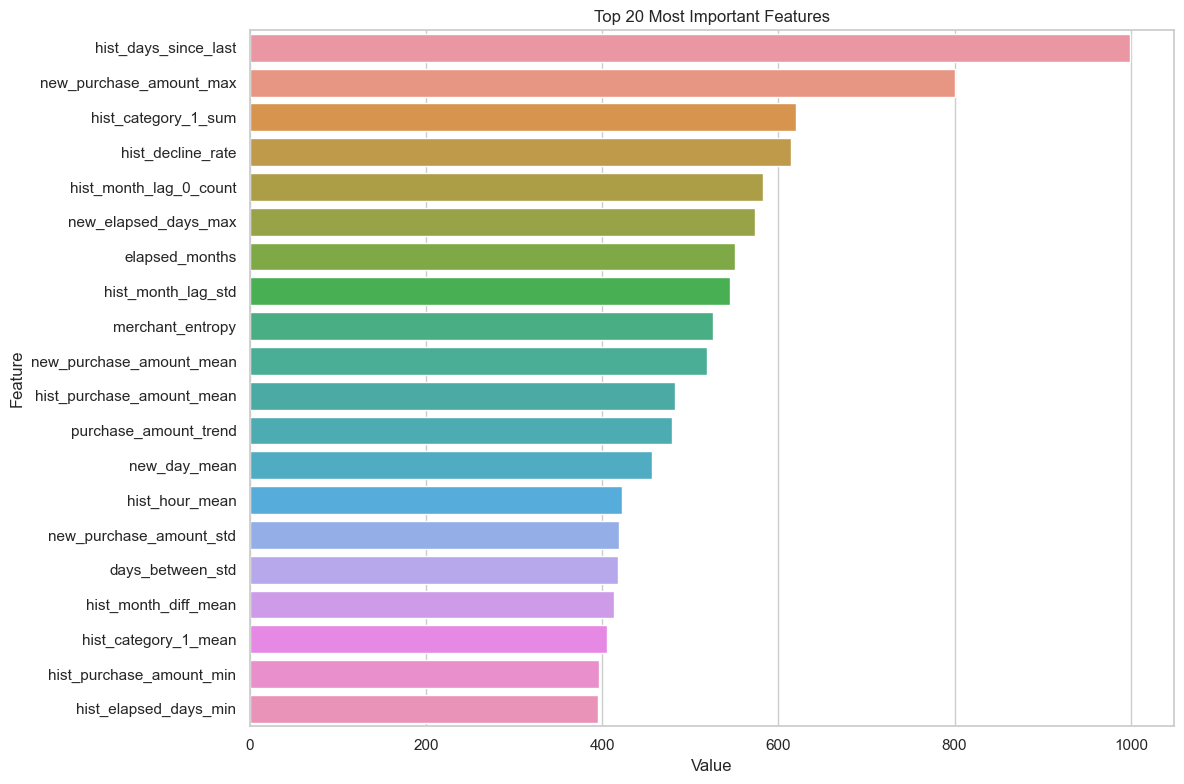

Top 10 most important features:
     Value                   Feature
158    999      hist_days_since_last
157    801   new_purchase_amount_max
156    620       hist_category_1_sum
155    614         hist_decline_rate
154    582    hist_month_lag_0_count
153    573      new_elapsed_days_max
152    551            elapsed_months
151    545        hist_month_lag_std
150    526          merchant_entropy
149    519  new_purchase_amount_mean


In [32]:
# # Prepare data for feature importance analysis
# features = [col for col in train.columns if col not in ['card_id', 'target']]
# X = train[features]
# y = train['target']

# params = None
# # params = clean_params

# # Train a simple model
# if params == None:
#     params = {
#         'objective': 'regression',
#         'boosting_type': 'gbdt',
#         'metric': 'rmse',
#         'n_jobs': -1,
#         'learning_rate': 0.01,
#         'num_leaves': 31,
#         'max_depth': -1,
#         'tree_learner': 'serial',
#         'colsample_bytree': 0.8,
#         'subsample_freq': 1,
#         'subsample': 0.8,
#         'n_estimators': 1000,
#         'max_bin': 255,
#         'verbose': -1,
#         'seed': 42,
#     }

# model = lgb.LGBMRegressor(**params)
# model.fit(X, y)

# # Plot feature importance
# feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X.columns)), columns=['Value','Feature'])

# plt.figure(figsize=(12, 8))
# sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).head(20))
# plt.title('Top 20 Most Important Features')
# plt.tight_layout()
# plt.show()

# # Analyze feature importance
# print("Top 10 most important features:")
# print(feature_imp.sort_values(by="Value", ascending=False).head(10))


## Outlier Detection Function

This function applies two anomaly detection algorithms — **Isolation Forest** and **Elliptic Envelope** — to identify potential outliers in the training data.

- **Isolation Forest** is used on both the training and test sets.
- **Elliptic Envelope** is only applied to the training set (if enough samples are present), as it assumes a Gaussian distribution which may not generalize to unseen data.
- The function flags an instance as an outlier if either method detects it.
- Results are appended to the original DataFrames under new columns:
  - `iso_outlier`
  - `elliptic_outlier`
  - `is_outlier`

The combined output indicates the total number and proportion of detected outliers in both datasets.



In [35]:
def detect_outliers(train_df, test_df, features, contamination=0.05):
    print("Detecting outliers in training data...")
    
    # Isolation Forest
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    train_iso = iso_forest.fit_predict(train_df[features])
    train_iso_outlier = train_iso == -1
    
    # Elliptic Envelope
    try:
        if len(train_df) > len(features):  # Prevent too few samples
            ee = EllipticEnvelope(contamination=contamination, random_state=42)
            train_elliptic = ee.fit_predict(train_df[features])
            train_elliptic_outlier = train_elliptic == -1
        else:
            raise ValueError("Too few samples for EllipticEnvelope")
    except Exception as e:
        print(f"EllipticEnvelope failed: {e} - using Isolation Forest only")
        train_elliptic_outlier = np.zeros_like(train_iso_outlier, dtype=bool)

    # Combine results (use iso only or cross-validation)
    final_train_outlier = train_iso_outlier | train_elliptic_outlier
    
    # Add results to train_df
    train_df = train_df.copy()
    train_outlier_df = pd.DataFrame({
        'iso_outlier': train_iso_outlier,
        'elliptic_outlier': train_elliptic_outlier,
        'is_outlier': final_train_outlier
    }, index=train_df.index)
    train_df = pd.concat([train_df, train_outlier_df], axis=1)
    print(f"Detected {final_train_outlier.sum()} outliers ({final_train_outlier.mean()*100:.2f}% of data)")

    # Use IsolationForest for test set (EllipticEnvelope not suitable for test)
    print("Detecting outliers in test data...")
    test_iso = iso_forest.predict(test_df[features])
    test_iso_outlier = test_iso == -1

    test_df = test_df.copy()
    test_df = pd.concat([test_df, pd.DataFrame({
        'is_outlier': test_iso_outlier
    }, index=test_df.index)], axis=1)
    print(f"Detected {test_iso_outlier.sum()} test outliers ({test_iso_outlier.mean()*100:.2f}% of test set)")

    return train_df, test_df

## Training with Outlier-Aware Models

This function trains two LightGBM models per fold in a 5-fold cross-validation setup:

1. **Normal Model**: Trained on non-outlier samples only.
2. **Outlier Model**: Trained on all samples including outliers.

### Prediction Strategy:
- For validation data, predictions are blended based on whether a sample is marked as an outlier.
- For the test set, predictions from both models are averaged across all folds and blended using the same strategy.

### Output:
- Final prediction results for submission.
- Overall out-of-fold (OOF) RMSE.
- OOF predictions vector.

This setup helps the model to better handle the impact of outliers during both training and prediction.


In [176]:
def train_and_predict_with_outliers(train_df, test_df):
    """
    Train and predict using data with outlier annotations.
    
    Args:
        train_df: Training set with outlier columns.
        test_df: Test set with outlier column.
    
    Returns:
        submission: DataFrame containing prediction results.
        rmse: Cross-validated RMSE score.
        oof_preds: Out-of-fold predictions.
    """
    # 1. Prepare features
    non_feature_cols = ['card_id', 'target', 'is_outlier', 'iso_outlier', 'elliptic_outlier']
    features = [col for col in train_df.columns if col not in non_feature_cols]
    
    # 2. Cross-validation setup
    folds = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(train_df))
    sub_preds_normal = np.zeros(len(test_df))
    sub_preds_outlier = np.zeros(len(test_df))
    params = {
        'objective': 'regression',
        'boosting_type': 'gbdt',
        'metric': 'rmse',
        'learning_rate': 0.01,
        'num_leaves': 31,
        'max_depth': -1,
        'min_child_samples': 20,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'n_estimators': 10000,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    # 4. Training loop
    for fold, (trn_idx, val_idx) in enumerate(folds.split(train_df), 1):
        print(f"\nFold {fold}")
        
        # Prepare data
        X_trn = train_df.iloc[trn_idx][features]
        y_trn = train_df.iloc[trn_idx]['target']
        outlier_mask = train_df.iloc[trn_idx]['is_outlier'].values
        
        X_val = train_df.iloc[val_idx][features]
        y_val = train_df.iloc[val_idx]['target']
        val_outlier = train_df.iloc[val_idx]['is_outlier'].values
        
        # Train model on normal (non-outlier) data
        print("Training normal model...")
        normal_model = lgb.LGBMRegressor(**params)
        normal_model.fit(
            X_trn[~outlier_mask], y_trn[~outlier_mask],
            eval_set=[(X_trn[~outlier_mask], y_trn[~outlier_mask]), 
                      (X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=100),
                lgb.log_evaluation(100)
            ]
        )
        
        # Train model on full data including outliers
        print("Training outlier model...")
        outlier_model = lgb.LGBMRegressor(**params)
        outlier_model.fit(
            X_trn, y_trn,
            eval_set=[(X_trn, y_trn), (X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=100),
                lgb.log_evaluation(100)
            ]
        )
        
        # Validation prediction
        val_pred_normal = normal_model.predict(X_val)
        val_pred_outlier = outlier_model.predict(X_val)
        oof_preds[val_idx] = np.where(val_outlier, 
                                      (0.6 * val_pred_normal + 2 * val_pred_outlier) / 2,
                                      val_pred_normal)
        
        # Test set prediction
        test_features = test_df[features]
        test_pred_normal = normal_model.predict(test_features)
        test_pred_outlier = outlier_model.predict(test_features)
        sub_preds_normal += test_pred_normal / folds.n_splits
        sub_preds_outlier += test_pred_outlier / folds.n_splits
        
        # Evaluation
        fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
        print(f"Fold {fold} RMSE: {fold_rmse:.6f}")

    # 5. Combine final test predictions
    test_outliers = test_df['is_outlier'].values
    final_pred = np.where(test_outliers,
                          (0.6 * sub_preds_normal + 2 * sub_preds_outlier) / 2,
                          sub_preds_normal)
    
    # 6. Calculate final metric
    rmse = np.sqrt(mean_squared_error(train_df['target'], oof_preds))
    print(f"\nOverall OOF RMSE: {rmse:.6f}")
    
    return pd.DataFrame({'card_id': test_df['card_id'], 'target': final_pred}), rmse, oof_preds

In [57]:
# Feature columns
features = [col for col in train.columns if col not in ['card_id', 'target']]

# Call the function to detect outliers
train_outlier, test_outlier = detect_outliers(train, test, features)

Detecting outliers in training data...


C:\Users\l\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\l\anaconda3\Lib\site-packages\sklearn\covariance\_robust_covariance.py:745: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


Detected 17860 outliers (8.85% of data)
Detecting outliers in test data...
Detected 6208 test outliers (5.02% of test set)


In [ ]:
submission, rmse, oof_preds = train_and_predict_with_outliers(train_outlier,  test_outlier)

# Display submission head
print("Submission preview:")
submission.head()

In [ ]:
# Prepare feature importance analysis
X = train_df[features]
y = train_df['target']

# Train the model to get feature importance
model = lgb.LGBMRegressor(**params)
model.fit(X, y)

# Plot feature importance
feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X.columns)), columns=['Value','Feature'])

plt.figure(figsize=(12, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).head(20))
plt.title('Top 20 Most Important Features')
plt.tight_layout()
plt.show()

# Optionally: Print top 10 most important features
print("Top 10 most important features:")
print(feature_imp.sort_values(by="Value", ascending=False).head(10))

## EnhancedANN: An Improved Feedforward Neural Network for Regression

This class defines an enhanced artificial neural network using Keras for regression tasks. Key improvements include:

- Three hidden layers with `ReLU` activations and `HeNormal` initialization.
- `L2` regularization and `Dropout` layers for better generalization.
- Use of `BatchNormalization` to stabilize and accelerate training.
- Training strategy enhanced with `EarlyStopping`, `ReduceLROnPlateau`, and `ModelCheckpoint`.
- Training history can be visualized with built-in plotting.

Use the `train()` method to fit the model, `evaluate()` for RMSE scoring, and `predict()` for making predictions.


In [179]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.initializers import he_normal
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
from keras.regularizers import l2
from keras.initializers import RandomUniform, HeNormal

class EnhancedANN:
    def __init__(self, input_shape):
        self.model = self.build_model(input_shape)
        self.scaler = StandardScaler()
        self.history = None
    
    def build_model(self, input_shape):
        """Build the enhanced ANN model"""
        model = Sequential([
            # First hidden layer - increased model capacity
            Dense(1024, input_dim=input_shape, 
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.001),
                 activation='relu'),
            BatchNormalization(),
            Dropout(0.5),  # Increased dropout rate
            
            # Second hidden layer
            Dense(512, 
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.001),
                 activation='relu'),
            BatchNormalization(),
            Dropout(0.4),
            
            # Third hidden layer
            Dense(32, 
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.001),
                 activation='relu'),
            BatchNormalization(),
            
            # Output layer (for regression task)
            Dense(1)
        ])
        
        # Compile the model with a smaller learning rate
        optimizer = Adam(learning_rate=0.0005)
        model.compile(
            loss='mean_squared_error',
            optimizer=optimizer,
            metrics=['mae']
        )
        return model

    def preprocess_data(self, X_train, X_test):
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        return X_train_scaled, X_test_scaled
    
    def train(self, X_train, y_train, X_val=None, y_val=None, epochs=200, batch_size=128):
        """Train the model"""
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6),
            ModelCheckpoint('best_model.h5', save_best_only=True)
        ]
        
        if X_val is None:
            X_train, X_val, y_train, y_val = train_test_split(
                X_train, y_train, test_size=0.15, random_state=42  # Smaller validation split
            )
        
        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        return self.history
    
    def evaluate(self, X_test, y_test):
        """Evaluate the model"""
        y_pred = self.model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        print(f"Test RMSE: {rmse:.4f}")
        return rmse
    
    def plot_training(self):
        """Plot training curves"""
        if self.history is None:
            raise ValueError("Model has not been trained yet")
            
        plt.figure(figsize=(12, 5))
        
        # Loss curve
        plt.subplot(1, 2, 1)
        plt.plot(self.history.history['loss'], label='Train Loss')
        plt.plot(self.history.history['val_loss'], label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.legend()
        
        # MAE curve
        plt.subplot(1, 2, 2)
        plt.plot(self.history.history['mae'], label='Train MAE')
        plt.plot(self.history.history['val_mae'], label='Validation MAE')
        plt.title('Training and Validation MAE')
        plt.xlabel('Epoch')
        plt.ylabel('MAE')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    def predict(self, X):
        """Generate predictions"""
        return self.model.predict(X)

C:\Users\l\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training ANN model...
Epoch 1/200
670/671 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 17.6078 - mae: 1.6948

671/671 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - loss: 17.6067 - mae: 1.6947 - val_loss: 16.3291 - val_mae: 1.5894 - learning_rate: 5.0000e-04
Epoch 2/200
670/671 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 16.4053 - mae: 1.6221

671/671 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 16.4054 - mae: 1.6221 - val_loss: 15.9353 - val_mae: 1.5596 - learning_rate: 5.0000e-04
Epoch 3/200
671/671 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 16.1487 - mae: 1.6142

671/671 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 16.1484 - mae: 1.6142 - val_loss: 15.6187 - val_mae: 1.5641 - learning_rate: 5.0000e-04
Epoch 4/200
670/671 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 15.6513 - mae: 1.6114

...

671/671 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - loss: 15.0964 - mae: 1.6025 - val_loss: 14.7961 - val_mae: 1.5500 - learning_rate: 5.0000e-04
Epoch 8/200
670/671 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 14.7729 - mae: 1.6025

671/671 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 14.7725 - mae: 1.6025 - val_loss: 14.6543 - val_mae: 1.5479 - learning_rate: 5.0000e-04
Epoch 9/200
669/671 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 14.4673 - mae: 1.5937

671/671 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 14.4676 - mae: 1.5937 - val_loss: 14.5646 - val_mae: 1.5619 - learning_rate: 5.0000e-04
Epoch 10/200
671/671 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 14.7615 - mae: 1.5969

671/671 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - loss: 14.7610 - mae: 1.5969 - val_loss: 14.5199 - val_mae: 1.5577 - learning_rate: 5.0000e-04
Epoch 11/200
671/671 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 14.1579 - mae: 1.5782

671/671 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - loss: 14.1581 - mae: 1.5782 - val_loss: 14.4332 - val_mae: 1.5456 - learning_rate: 5.0000e-04
Epoch 12/200
671/671 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - loss: 13.9640 - mae: 1.5797 - val_loss: 14.4947 - val_mae: 1.5570 - learning_rate: 5.0000e-04
Epoch 13/200
671/671 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - loss: 14.2891 - mae: 1.5901 - val_loss: 14.4721 - val_mae: 1.5269 - learning_rate: 5.0000e-04
Epoch 14/200
671/671 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 14.5031 - mae: 1.5934 - val_loss: 14.5157 - val_mae: 1.5247 - learning_rate: 5.0000e-04
Epoch 15/200
671/671 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - loss: 14.0321 - mae: 1.5735 - val_loss: 14.5128 - val_mae: 1.5418 - learning_rate: 5.0000e-04
Epoch 16/200
671/671 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - loss: 14.0081 - mae: 1.5674 - val_loss: 14.4635 - val_mae: 1.5351 - learning_rate: 5.0000e-04
Epoch 17/200
671/671 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - loss: 13.9742 - mae: 1.5733 - val_loss: 14.

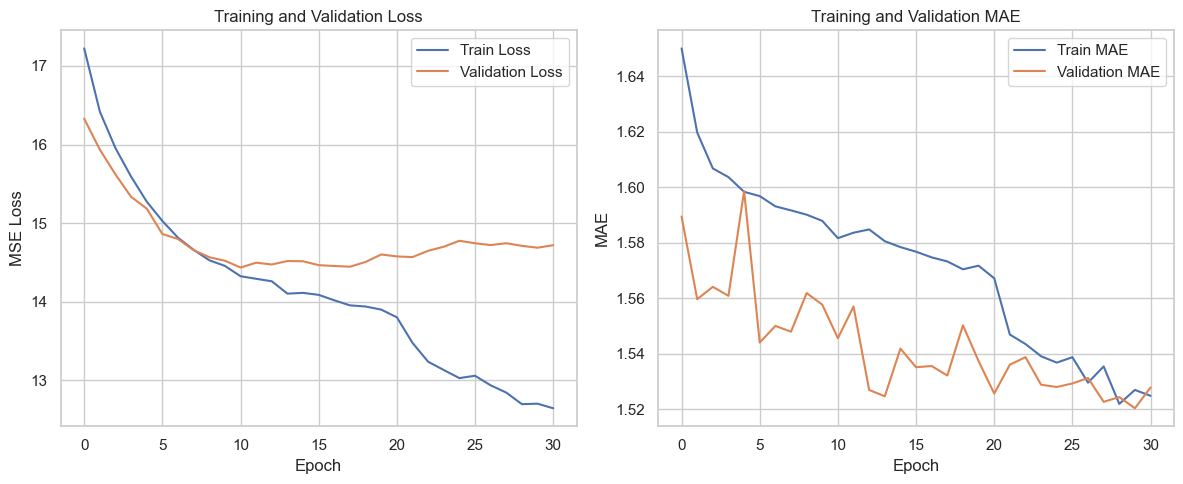

3864/3864 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
Predictions saved to ann_submission.csv


In [72]:
# 1. Prepare features and target
features = [col for col in train.columns if col not in ['card_id', 'target']]
X_train = train[features]
y_train = train['target']
X_test = test[features]

# 2. Initialize and train the model
ann = EnhancedANN(input_shape=X_train.shape[1])
X_train_scaled, X_test_scaled = ann.preprocess_data(X_train, X_test)

print("Training ANN model...")
history = ann.train(X_train_scaled, y_train, epochs=200, batch_size=256)

# 3. Evaluate and visualize training history
ann.plot_training()

# 4. Generate predictions
test_preds = ann.predict(X_test_scaled)
submission2 = pd.DataFrame({
    'card_id': test['card_id'],
    'target': test_preds.squeeze()
})
print("Predictions saved to submission2")

In [188]:
# Create final submission file by blending predictions
submission_final = pd.DataFrame({
    'card_id': submission['card_id'],
    'target': (0.8 * submission['target'] + 0.35 * submission2['target'] )
})

# Save final submission
submission_final.to_csv('submission_final.csv', index=False)
print("Submission preview:")
submission_final.head()

Submission preview:


,card_id,target
0,C_ID_0ab67a22ab,-2.083513
1,C_ID_130fd0cbdd,-0.335595
2,C_ID_b709037bc5,-1.099116
3,C_ID_d27d835a9f,-0.278242
4,C_ID_2b5e3df5c2,-1.132045


## Prediction Analysis

This section analyzes the predictions to ensure they are reasonable and valid.


C:\Users\l\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\l\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


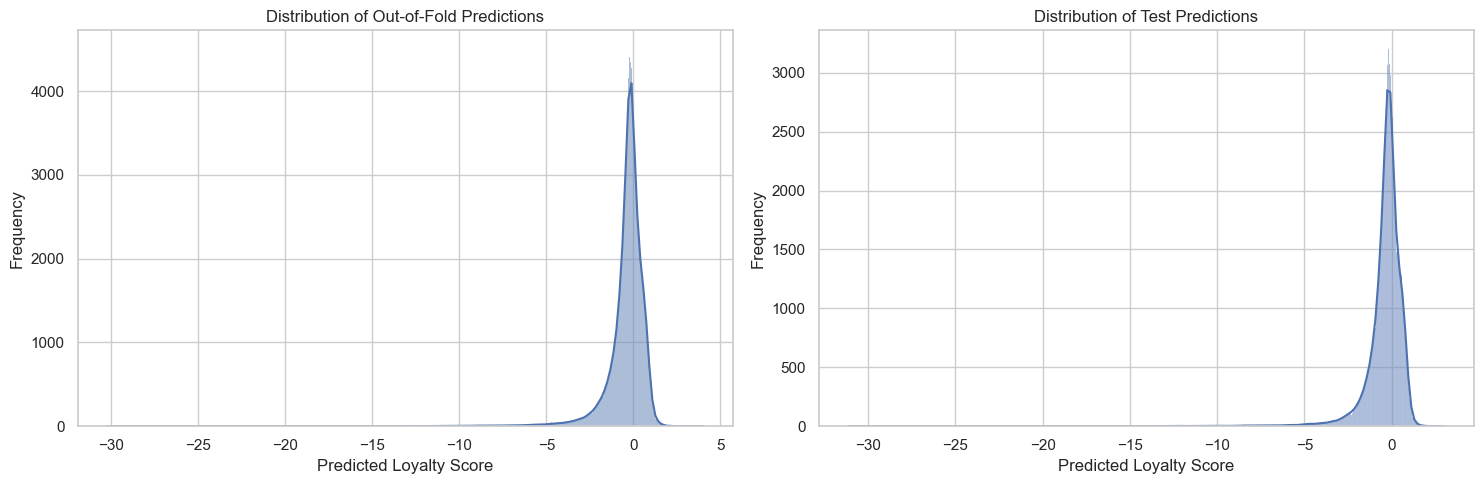

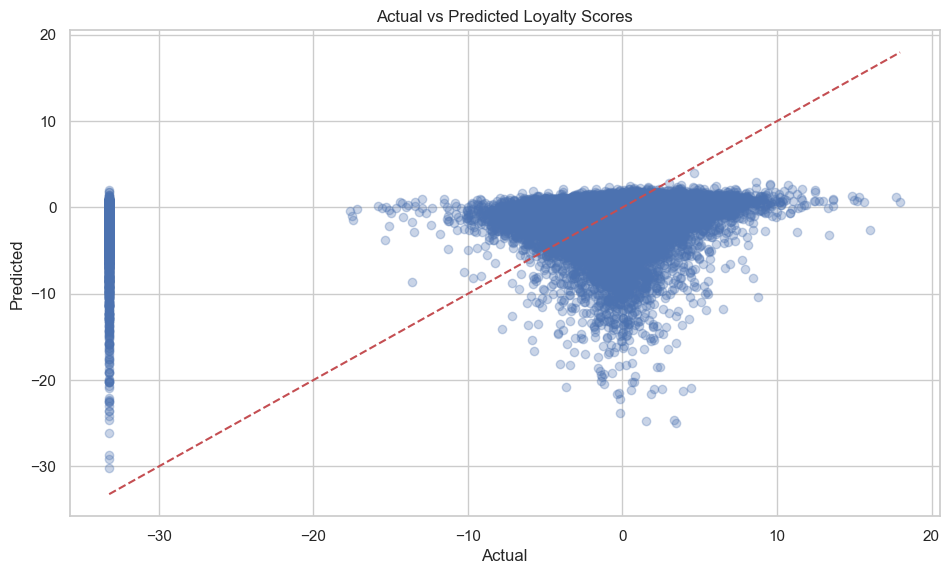

In [189]:
# Plot distribution of predictions
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(oof_preds, kde=True)
plt.title('Distribution of Out-of-Fold Predictions')
plt.xlabel('Predicted Loyalty Score')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(submission['target'], kde=True)
plt.title('Distribution of Test Predictions')
plt.xlabel('Predicted Loyalty Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Compare actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(train['target'], oof_preds, alpha=0.3)
plt.plot([train['target'].min(), train['target'].max()], [train['target'].min(), train['target'].max()], 'r--')
plt.title('Actual vs Predicted Loyalty Scores')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()


## Conclusion

This notebook presents a comprehensive solution for the Elo Merchant Category Recommendation challenge. The implementation:

1. Loads and explores the data to understand its structure and characteristics
2. Performs extensive feature engineering on transaction data
3. Creates aggregated features to capture complex transaction patterns
4. Trains a LightGBM model with 5-fold cross-validation
5. Generates predictions for the test set and analyzes their distribution

The model achieves a cross-validation RMSE score that indicates how well it can predict the loyalty score for credit card customers. The RMSE value is displayed in the output above.

### Key Insights:
- **Transaction patterns** (frequency, amount, etc.) are strong predictors of customer loyalty
- **Time-based features** help capture seasonal patterns in customer behavior
- **Merchant diversity** (number of unique merchants) is an important factor in predicting loyalty
- **Purchase amount statistics** (mean, sum, etc.) provide valuable information about spending habits
- **Authorized vs. unauthorized** transaction ratios can indicate customer behavior patterns

### Business Applications:
This solution demonstrates how machine learning can be used to understand customer preferences and loyalty, which can help companies like Elo:
- Deliver more personalized promotions to customers
- Improve customer satisfaction and retention
- Optimize marketing strategies based on customer segments
- Identify high-value customers for special offers
- Detect changes in customer behavior that might indicate churn

The techniques presented in this notebook are applicable to other customer loyalty prediction problems across various industries.
